# **Лабораторна робота №4**

Виконавець:  <b>Бережна Ольга</b>, група <b>К-27</b>
<br> Викладач: <b>Карнаух Тетяна Олександрівна</b>

<b>Задача 2.</b> У завданні 4 лабораторної роботи №2 оброблялися значення функції у точках. Побудувати графік цієї функції (кусково-лінійне наближення). На тому самому зображенні іншим кольором побудувати графік знайденої в результаті обчислень функції.

In [1]:
import numpy as np
import scipy, scipy.linalg as la
import pandas as pd
import matplotlib, matplotlib.pyplot as plt

Зчитуємо дані з CSV-файлу. Оскільки для кожного значення $n$ проводилося кілька експериментів, ми групуємо дані за параметром $n$ та обчислюємо середнє значення часу $t$, щоб зменшити вплив випадкових похибок вимірювання.

In [2]:
raw = pd.read_csv('lab2_var102.csv')

In [3]:
task4 = raw.groupby('n')['t'].mean().reset_index()
n_exp = task4['n']
t_exp = task4['t']

Логарифмуємо дані та використаємо метод найменших квадратів (МНК), щоб знайти оцінки параметрів $a$, $c$ функції $T(n)\approx cn^a$.

In [4]:
task4['ln n'] = np.log(task4['n'])
task4['ln t'] = np.log(task4['t'])
task4['const'] = 1

In [5]:
X = task4[['const', 'ln n']].to_numpy()
Y = task4['ln t'].to_numpy()
res = la.lstsq(X, Y)[0]

In [6]:
a = res[1]
c = np.exp(res[0])

In [7]:
print(f'{c = :.6f}, {a = :.6f}')

c = 2.307785, a = 0.698646


Отриманий масив точок, які рівномірно розташовані по всій шкалі, запам'ятаємо в змінній <code>scale</code> та обчислимо розрахункові значення функції часової складності на всій шкалі і запам'ятаємо в змінній <code>times</code>.

In [8]:
scale = np.linspace(raw['n'].min(), raw['n'].max(), 500)
times = c * (scale ** a)

Будуємо два графіки на одній площині:
<br>1.Кусково-лінійне наближення (червона лінія) — демонструє реальні експериментальні дані.
<br>2.Теоретична модель (синій пунктир) — плавна крива, побудована за знайденими параметрами $a$ та $c$.

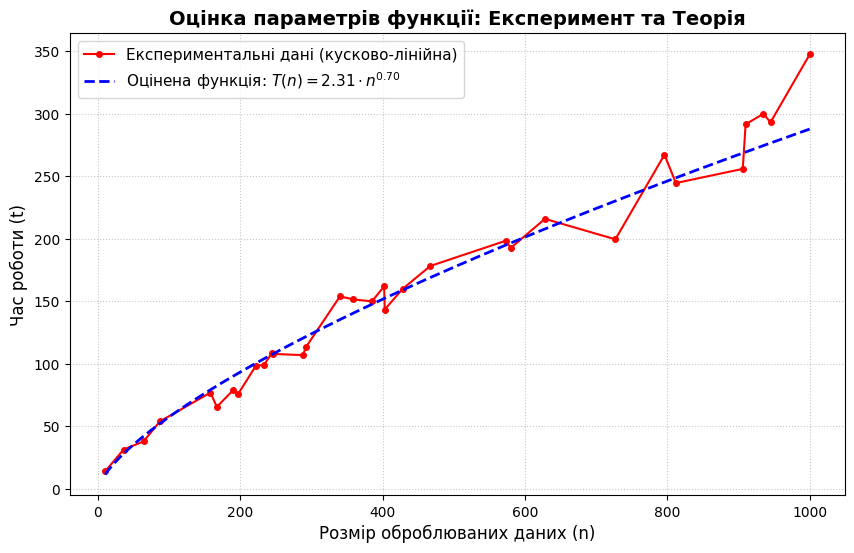

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(n_exp, t_exp, color='red', marker='o', markersize=4, linestyle='-',
         label='Експериментальні дані (кусково-лінійна)')

plt.plot(scale, times, color='blue', linestyle='--', linewidth=2, 
         label=f'Оцінена функція: $T(n) = {c:.2f} \\cdot n^{{{a:.2f}}}$')

plt.title('Оцінка параметрів функції: Експеримент та Теорія', fontsize=14, fontweight='bold')
plt.xlabel('Розмір оброблюваних даних (n)', fontsize=12)
plt.ylabel('Час роботи (t)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.savefig('plot_task2_final.png', bbox_inches='tight')
plt.show()